# Phishing Detection with Machine Learning — A Comparative Study of Classical Classifiers
**PROM02 — MSc Cybersecurity project** · Igbinosa Collins Osakponmwen (250356287)

This notebook implements the full machine-learning pipeline for the project: it loads a
labelled phishing dataset, trains and tunes **five classical classifiers**
(Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost) through one
controlled pipeline, evaluates them on a held-out test set, explains the best
model with **SHAP**, and saves the chosen model for deployment in the web app.

**How the data loads:** the notebook first tries to download the real
*UCI Phishing Websites Dataset* (`id=327`). If there is no internet (or the
download is blocked), it falls back to a synthetic dataset with the **identical
30-feature schema** and a built-in learnable signal, so the notebook always runs
end-to-end. When you run it on your own machine with internet, you get the real data.


## Step 0 — Imports
If a package is missing, install it with:
```
pip install scikit-learn xgboost shap ucimlrepo matplotlib seaborn pandas
```

In [1]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay)
import shap, joblib

SEED = 42  # fixed seed everywhere -> reproducible results (Objective O4)
np.random.seed(SEED)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load the data
Each row is a website described by 30 features (values in {-1, 0, 1}) plus a label.
We map the label to **1 = phishing, 0 = legitimate**.

In [2]:
UCI_FEATURES = [
    "having_IP_Address","URL_Length","Shortining_Service","having_At_Symbol",
    "double_slash_redirecting","Prefix_Suffix","having_Sub_Domain","SSLfinal_State",
    "Domain_registeration_length","Favicon","port","HTTPS_token","Request_URL",
    "URL_of_Anchor","Links_in_tags","SFH","Submitting_to_email","Abnormal_URL",
    "Redirect","on_mouseover","RightClick","popUpWidnow","Iframe","age_of_domain",
    "DNSRecord","web_traffic","Page_Rank","Google_Index","Links_pointing_to_page",
    "Statistical_report"]

def make_synthetic(n=11055, seed=SEED):
    """Faithful offline stand-in: real UCI schema + a learnable signal."""
    rng = np.random.default_rng(seed)
    three = {"URL_Length","having_Sub_Domain","URL_of_Anchor","Links_in_tags",
             "web_traffic","Links_pointing_to_page"}
    X = pd.DataFrame({f: rng.choice([-1,0,1] if f in three else [-1,1], size=n)
                      for f in UCI_FEATURES})
    w = {f: rng.normal(0,0.4) for f in UCI_FEATURES}
    w.update({"SSLfinal_State":1.4,"URL_of_Anchor":1.2,"web_traffic":0.9,
              "having_Sub_Domain":0.8,"Prefix_Suffix":0.8,"Request_URL":0.6,
              "age_of_domain":0.6,"having_IP_Address":0.7,"Google_Index":0.6})
    logit = sum(w[f]*X[f].values for f in UCI_FEATURES) + rng.normal(0,1.3,n)
    X["Result"] = np.where(1/(1+np.exp(-logit)) > 0.5, 1, -1)  # 1=legit, -1=phish
    return X

def load_data():
    try:
        from ucimlrepo import fetch_ucirepo
        d = fetch_ucirepo(id=327)
        X = d.data.features.copy()
        y = d.data.targets.iloc[:, 0].copy()
        source = "UCI Phishing Websites Dataset (online, id=327)"
    except Exception as e:
        print("Online fetch unavailable -> using synthetic fallback.")
        df = make_synthetic()
        X = df.drop(columns=["Result"]); y = df["Result"]
        source = "Synthetic fallback (same 30-feature schema)"
    y = (y == -1).astype(int)   # 1 = phishing, 0 = legitimate
    return X, y, source

X, y, SOURCE = load_data()
print("Source:", SOURCE)
print("Shape:", X.shape, "| phishing rate: %.3f" % y.mean())
X.head()

Source: UCI Phishing Websites Dataset (online, id=327)
Shape: (11055, 30) | phishing rate: 0.443


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1


### Class balance
A roughly balanced dataset means accuracy is meaningful, but we still report precision/recall/F1.

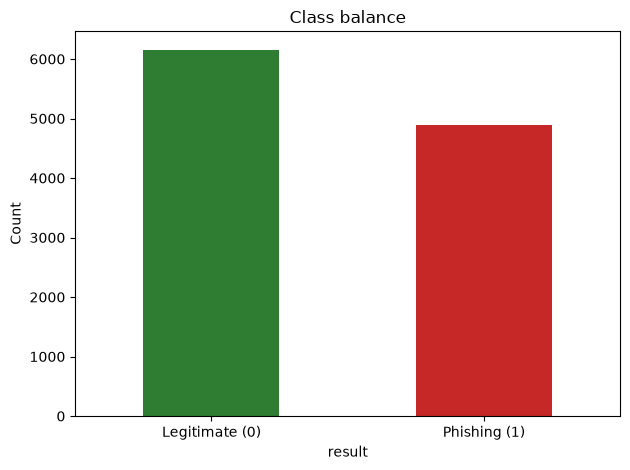

{0: 6157, 1: 4898}


In [3]:
ax = y.value_counts().sort_index().plot(kind="bar", color=["#2E7D32","#C62828"])
ax.set_xticklabels(["Legitimate (0)","Phishing (1)"], rotation=0)
ax.set_title("Class balance"); ax.set_ylabel("Count"); plt.tight_layout(); plt.show()
print(y.value_counts().to_dict())

## Step 2 — Train / test split
We hold back 20% as a test set the models never see during training or tuning.
`stratify=y` keeps the class ratio identical in both splits.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (8844, 30) | Test: (2211, 30)


## Steps 3–5 — Define, train and tune the five models
Each model goes through the **same** `GridSearchCV` with **5-fold cross-validation**
(scoring on F1). Linear models (Logistic Regression, SVM) are wrapped with a
`StandardScaler`; tree-based models don't need scaling. We record training time
and per-sample prediction latency for the comparison.

In [5]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=SEED),
                            {"clf__C": [0.1, 1, 10]}, True),
    "Decision Tree": (DecisionTreeClassifier(random_state=SEED),
                      {"clf__max_depth": [6, 10, None]}, False),
    "Random Forest": (RandomForestClassifier(random_state=SEED, n_jobs=-1),
                      {"clf__n_estimators": [200], "clf__max_depth": [10, None]}, False),
    "SVM (RBF)": (SVC(probability=True, random_state=SEED),
                  {"clf__C": [10], "clf__gamma": ["scale"]}, True),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=SEED,
                              n_jobs=-1, verbosity=0),
                {"clf__n_estimators": [300], "clf__max_depth": [4, 6]}, False),
}

rows, fitted = [], {}
for name, (est, grid, scale) in models.items():
    steps = ([("scaler", StandardScaler())] if scale else []) + [("clf", est)]
    pipe = Pipeline(steps)
    t0 = time.perf_counter()
    gs = GridSearchCV(pipe, grid, cv=5, scoring="f1", n_jobs=-1).fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    best = gs.best_estimator_
    t1 = time.perf_counter()
    proba = best.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    latency_ms = (time.perf_counter() - t1) / len(X_test) * 1000
    fitted[name] = {"model": best, "proba": proba, "pred": pred}
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC_AUC": roc_auc_score(y_test, proba),
                 "Train_time_s": round(train_time, 2),
                 "Latency_ms": round(latency_ms, 4)})
    print(f"{name:20s} F1={rows[-1]['F1']:.4f}  AUC={rows[-1]['ROC_AUC']:.4f}  ({train_time:.1f}s)")

Logistic Regression  F1=0.9153  AUC=0.9783  (1.6s)


Decision Tree        F1=0.9651  AUC=0.9764  (1.0s)


Random Forest        F1=0.9738  AUC=0.9964  (0.8s)


SVM (RBF)            F1=0.9646  AUC=0.9937  (2.5s)


XGBoost              F1=0.9738  AUC=0.9968  (0.9s)


## Step 6 — Compare the models
This comparison table is the core research output — models are ranked by F1.

In [6]:
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
results = (pd.DataFrame(rows)
           .sort_values("F1", ascending=False)
           .reset_index(drop=True))
best_name = results.iloc[0]["Model"]
print("Best model by F1:", best_name)
results

Best model by F1: Random Forest


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_time_s,Latency_ms
0,Random Forest,0.9769,0.9804,0.9673,0.9738,0.9964,0.7700,0.0124
1,XGBoost,0.9769,0.9813,0.9663,0.9738,0.9968,0.8900,0.0010
2,Decision Tree,0.9692,0.9720,0.9582,0.9651,0.9764,1.0000,0.0003
3,SVM (RBF),0.9688,0.9710,0.9582,0.9646,0.9937,2.5000,0.0432
4,Logistic Regression,0.9263,0.9323,0.8990,0.9153,0.9783,1.5600,0.0004


### ROC curves

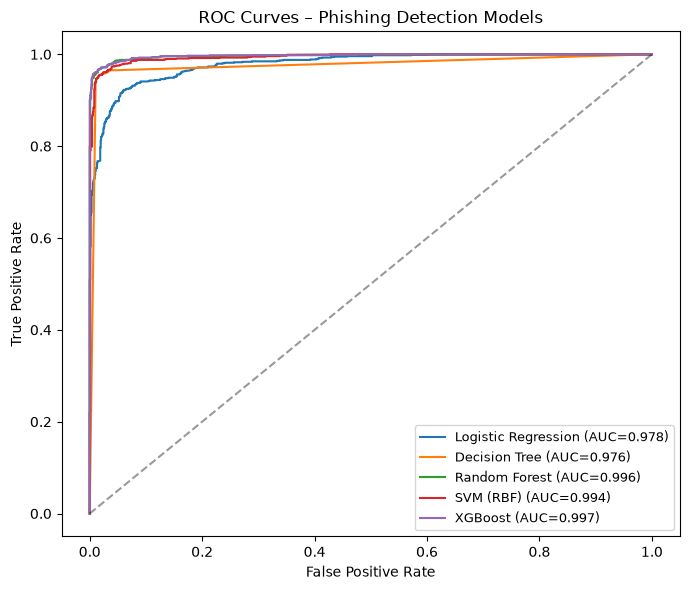

In [7]:
plt.figure(figsize=(7,6))
for name in fitted:
    fpr, tpr, _ = roc_curve(y_test, fitted[name]["proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--",alpha=.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Phishing Detection Models")
plt.legend(loc="lower right", fontsize=9); plt.tight_layout(); plt.show()

### Metric comparison bar chart

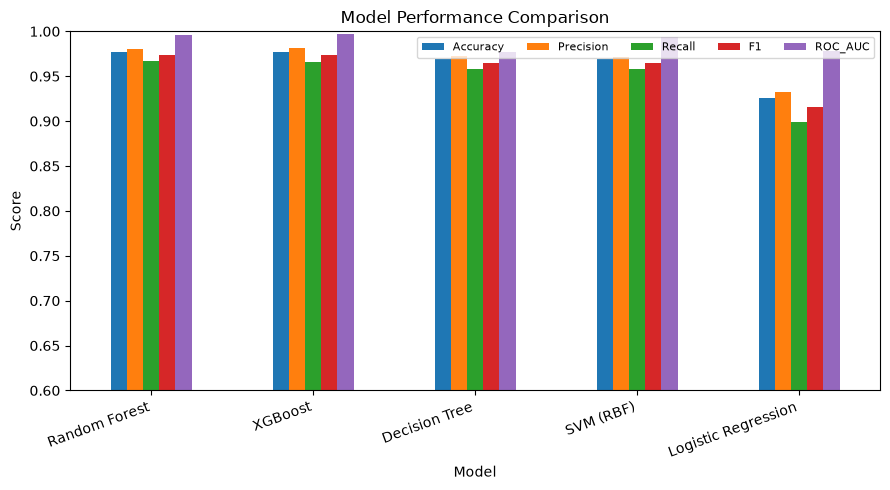

In [8]:
ax = results.set_index("Model")[["Accuracy","Precision","Recall","F1","ROC_AUC"]].plot(
    kind="bar", figsize=(9,5))
ax.set_ylim(0.6, 1.0); ax.set_ylabel("Score"); ax.set_title("Model Performance Comparison")
plt.xticks(rotation=20, ha="right"); plt.legend(fontsize=8, ncol=5); plt.tight_layout(); plt.show()

### Confusion matrix for the best model

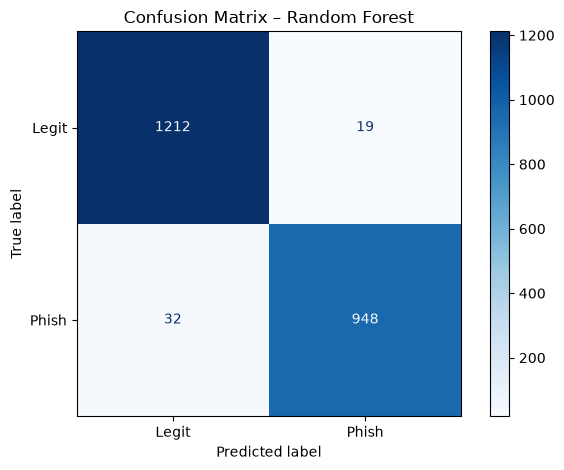

In [9]:
cm = confusion_matrix(y_test, fitted[best_name]["pred"])
ConfusionMatrixDisplay(cm, display_labels=["Legit","Phish"]).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix – {best_name}"); plt.tight_layout(); plt.show()

## Step 7 — Explain the model with SHAP
SHAP shows which features push a prediction toward *phishing* or *legitimate*.
We use the Random Forest (a tree model) because tree SHAP is fast and exact.
Each dot is one test website; red = high feature value, blue = low.

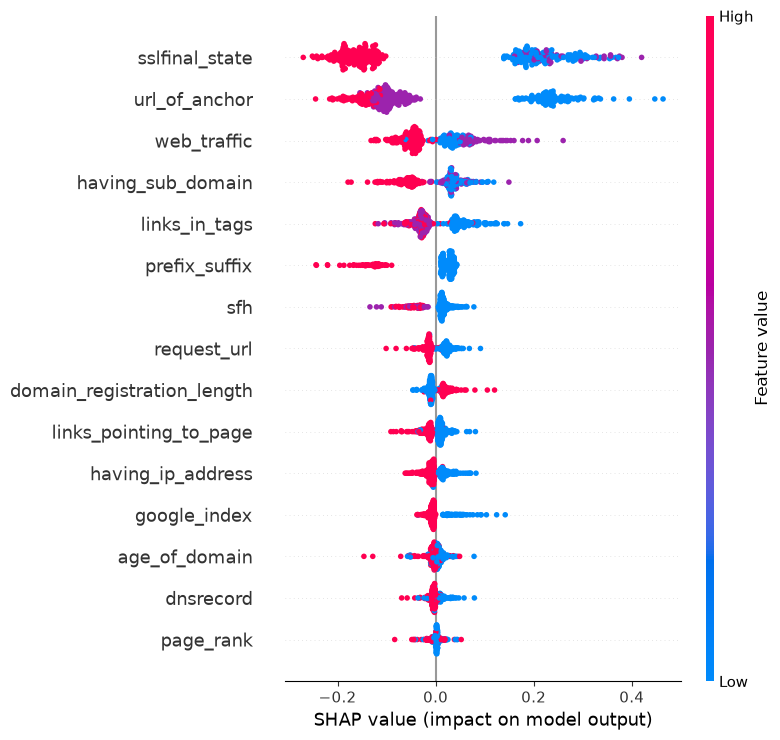

In [10]:
rf_pipe = fitted["Random Forest"]["model"]
# the model is a Pipeline ending in the classifier; TreeExplainer needs the raw tree estimator
rf = rf_pipe.named_steps["clf"] if hasattr(rf_pipe, "named_steps") else rf_pipe
explainer = shap.TreeExplainer(rf)
sample = X_test.sample(min(400, len(X_test)), random_state=SEED)
sv = explainer.shap_values(sample)
# handle scikit-learn / shap version differences in output shape
sv_pos = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if getattr(sv, "ndim", 2) == 3 else sv)
shap.summary_plot(sv_pos, sample, max_display=15, show=True)

## Step 8 — Save the best model for deployment
The serialised model is what the Streamlit web app loads to score pasted URLs.

In [11]:
joblib.dump(fitted[best_name]["model"], "best_model.joblib")
results.to_csv("model_comparison.csv", index=False)
print("Saved best_model.joblib and model_comparison.csv")
print("Selected model:", best_name)

Saved best_model.joblib and model_comparison.csv
Selected model: Random Forest


## Notes & next steps
- **Real data:** running this with internet pulls the genuine UCI dataset automatically.
  On the real data, tree-based models (Random Forest / XGBoost) typically lead; on the
  synthetic fallback the signal is linear, so Logistic Regression can win. Re-run and
  report whatever your data actually shows.
- **Your own URL features (Objective O3):** to score live URLs you'll add a feature
  extractor (e.g. `tldextract`, `python-whois`) that converts a raw URL into the same
  columns used here, then call `best_model.predict_proba()`.
- **Deployment (Objectives O6–O7):** load `best_model.joblib` in a Streamlit app for the
  pasted-URL mode, and reuse the same extractor + model in the email-forwarding webhook.
- **Reproducibility:** every random step is seeded (`SEED = 42`); commit this notebook,
  `model_comparison.csv` and `best_model.joblib` to your Git repository.
